# **Lab 03.2 - Introduction to Deep Q-Network**

##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>

This lab consists of 3 parts:
<ol style="margin-left: 20px;">
  <li><strong>Part 1: DQN on VacuumCleanerEnv</strong> - Custom environment with grid world and visual feedback</li>
  <li><strong>Part 2: DQN on LoadBalancingEnv</strong> - Multi-server task distribution problem</li>
  <li><strong>Part 3: Stable-Baselines3 DQN</strong> - Using production-ready RL library for faster implementation</li>
</ol>
</div>

### Imports and Setup

In [1]:
# ============================================================================
# Imports and runtime stability config
# ============================================================================

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

# Reduce thread contention in notebook kernels (more stable on shared/limited CPUs).
# Guard set_num_interop_threads so this block is re-runnable in an existing kernel.
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    # Safe to ignore when interop threads were already configured earlier in this session.
    pass

# Fixed seeds => easier to compare student results across runs
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Use GPU if available; otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Quick diagnostic print so students can verify runtime environment
print(f"\n{'='*60}")
print(f"Device: {device}")
print(f"PyTorch Version: {torch.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Gymnasium Version: {gym.__version__}")
print(f"Torch Threads: {torch.get_num_threads()}")
print(f"{'='*60}\n")


Device: cuda
PyTorch Version: 2.5.1+cu121
NumPy Version: 2.4.2
Gymnasium Version: 1.2.3
Torch Threads: 1



---

# Shared Components for DQN

The following classes (ReplayBuffer, DQNNetwork, DQNAgent) are reused across all parts of this lab. They are modular and can be adapted for different environments.

### Shared Component 1: Replay Buffer

In [2]:
# ============================================================================
# Shared component: replay buffer
# ============================================================================
# Why this matters:
#+ DQN learns better from randomly sampled past experiences than from strictly
#+ consecutive transitions (which are highly correlated).

class ReplayBuffer:
    """Store and sample experiences for DQN training.

    A transition has shape: (state, action, reward, next_state, done)
    """

    def __init__(self, capacity=10000):
        """Create bounded memory for transitions.

        Args:
            capacity: Maximum transitions kept in memory.
        """
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """Append one transition into replay memory."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """Randomly sample a mini-batch and convert to tensors on target device.

        Returns:
            states, actions, rewards, next_states, dones
        """
        # Instruction:
        # 1) Use random.sample to get a batch of transitions from self.buffer
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        batch = random.sample(self.buffer, batch_size)


        # Instruction:
        # 1) Convert each component (state/action/reward/next_state/done) to NumPy arrays.
        # 2) Convert arrays to torch tensors on `device`.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###

        states_np = np.array([t[0] for t in batch], dtype=np.float32)
        actions_np = np.array([t[1] for t in batch], dtype=np.int64)
        rewards_np = np.array([t[2] for t in batch], dtype=np.float32)
        next_states_np = np.array([t[3] for t in batch], dtype=np.float32)
        dones_np = np.array([t[4] for t in batch], dtype=np.float32)

        # 3) Convert numpy arrays to PyTorch tensors and move to device
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        states = torch.from_numpy(states_np).to(device)
        actions = torch.from_numpy(actions_np).to(device)
        rewards = torch.from_numpy(rewards_np).to(device)
        next_states = torch.from_numpy(next_states_np).to(device)
        dones = torch.from_numpy(dones_np).to(device)   
  
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

print("✓ ReplayBuffer class defined")


✓ ReplayBuffer class defined


### Shared Component 2: DQN Network

In [3]:
# ============================================================================
# Shared component: Q-network
# ============================================================================
# This neural network approximates Q(s, a) for all actions a at once.

class DQNNetwork(nn.Module):
    """Simple MLP-based Deep Q-Network."""
    
    def __init__(self, state_size, action_size, hidden_size=128):
        """Initialize network layers.

        Args:
            state_size: Number of features in state vector.
            action_size: Number of discrete actions.
            hidden_size: Width of hidden layer.
        """
        super(DQNNetwork, self).__init__()
        # Instruction:
        # 1) Define a linear layer (self.fc1) that maps state_size to
        #    a hidden layer of size 64
        # 2) Define a ReLU activation (self.relu)
        # 3) Define a linear layer (self.fc2) that maps the hidden layer
        #    to action_size (output Q-values for each action)
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        """Compute Q-values for each possible action given a state batch."""
        x = self.fc1(state)
        x = self.relu(x)
        q_values = self.fc2(x)
        return q_values

print("✓ DQNNetwork class defined")

✓ DQNNetwork class defined


### Shared Component 3: DQN Agent

In [4]:
# ============================================================================
# Shared component: DQN agent
# ============================================================================

class DQNAgent:
    """Reusable Deep Q-Learning agent for discrete-action environments."""

    def __init__(self, state_size, action_size, learning_rate=1e-3, gamma=0.99):
        """Initialize model, optimizer, and replay memory.

        Args:
            state_size: State feature dimension.
            action_size: Number of valid actions.
            learning_rate: Adam learning rate.
            gamma: Reward discount factor.
        """
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = gamma

        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995

        # Instruction:
        # 1) Create q_network and target_network as instances of DQNNetwork.
        # 2) Move networks to device (CPU or GPU).
        # 3) Initialize target_network weights to match q_network and set to eval mode.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.q_network = DQNNetwork(state_size, action_size).to(device)
        self.target_network = DQNNetwork(state_size, action_size).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)
        self.loss_fn = nn.MSELoss()

        self.replay_buffer = ReplayBuffer(capacity=10000)
        self.update_counter = 0

    def select_action(self, state, training=True):
        if training and random.random() < self.epsilon:
            return random.randint(0, self.action_size - 1)

        # Instruction:
        # Convert state to tensor shape [1, state_size], run q_network, return argmax action.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        state_array = np.array(state, dtype=np.float32)
        state_tensor = torch.FloatTensor(state_array).unsqueeze(0).to(device)

        with torch.no_grad():
            q_values = self.q_network(state_tensor)

        return q_values.argmax(dim=1).item()

    def store_transition(self, state, action, reward, next_state, done):
        state_array = np.array(state, dtype=np.float32)
        next_state_array = np.array(next_state, dtype=np.float32)
        self.replay_buffer.push(state_array, action, reward, next_state_array, done)

    def train_step(self, batch_size=32):
        if len(self.replay_buffer) < batch_size:
            return

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(batch_size)

        # Instruction:
        # Implement one DQN update step.
        # 1) Compute q_values for chosen actions.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        q_values = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # 2) Compute target_q_values using target network.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        with torch.no_grad():
            next_q_values = self.target_network(next_states).max(dim=1)[0]
            target_q_values = rewards + (1 - dones) * self.gamma * next_q_values    

        # 3) Compute MSE loss and optimize.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        loss = self.loss_fn(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # 4) Sync target network every 100 updates.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.update_counter += 1
        if self.update_counter % 100 == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):
        # Decay epsilon after each episode.
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

print("✓ DQNAgent class defined")


✓ DQNAgent class defined


---

# PART 1: DQN on VacuumCleanerEnv

A custom grid-based environment where the agent must clean a 5x5 grid by visiting all dirty cells.

**State cũ** (50 chiều):
- [0:25]: one-hot vị trí agent (25 ô)
- [25:50]: dirty mask (1=bẩn, 0=sạch)

**State mới** (51 chiều) - thêm thông tin:
- [0:25]: one-hot vị trí agent
- [25:50]: dirty mask  
- [50]: steps_remaining / max_steps (tỷ lệ bước còn lại)
  → Agent biết mình còn bao nhiêu thời gian để lên kế hoạch

## Cải tiến Reward Design

| Tình huống | Reward cũ | Reward mới | Lý do |
|---|---|---|---|
| Dọn ô mới | +10 | +10 | Giữ nguyên |
| Đi vào tường | -0.1 | -1.0 | Phạt mạnh để tránh lãng phí step |
| Đi lại ô cũ | -0.1 | -0.5 | Phạt trung bình để tránh lặp vòng |
| Hoàn thành toàn bộ | +0 | +50 | Khuyến khích mạnh mẽ |
| Di chuyển bình thường | -0.1 | -0.1 | Giữ nguyên |


### 1.1: Define VacuumCleanerEnv

Custom Gymnasium environment for vacuum cleaning task.

In [5]:
# ============================================================
# PART 1: VacuumCleanerEnv - PHIÊN BẢN CẢI TIẾN
# ============================================================

class VacuumCleanerEnv(gym.Env):
    """Môi trường robot hút bụi 5x5 - phiên bản cải tiến.
    
    CẢI TIẾN SO VỚI BẢN CŨ:
    1. Reward mạnh hơn cho penalty tường và lặp ô
    2. Completion bonus lớn khi dọn sạch toàn bộ
    3. State thêm thông tin steps_remaining
    4. Track previous_pos để phát hiện đi vào tường
    """
    
    def __init__(self, grid_size=5):
        super().__init__()
        self.grid_size = grid_size
        self.num_cells = grid_size * grid_size   # 25 ô
        
        # 4 action: 0=lên, 1=xuống, 2=trái, 3=phải
        self.action_space = spaces.Discrete(4)
        
        # State: 51 chiều = 25 (vị trí) + 25 (dirty) + 1 (steps_ratio)
        self.observation_space = spaces.Box(
            low=0, high=1, shape=(51,), dtype=np.float32
        )
        
        self.agent_pos    = 0
        self.dirty_cells  = set()
        self.steps        = 0
        self.max_steps    = 200          # Tăng từ 100 lên 200 để đủ thời gian
        self.total_reward = 0.0
        self.previous_pos = 0            # Để detect đi vào tường
    
    def _get_state(self):
        """Encode state thành vector 51 chiều."""
        state = np.zeros(51, dtype=np.float32)
        
        # Kênh 1: One-hot vị trí (index 0-24)
        state[self.agent_pos] = 1.0
        
        # Kênh 2: Dirty mask (index 25-49)
        for cell in self.dirty_cells:
            state[25 + cell] = 1.0
        
        # Kênh 3: Tỷ lệ bước còn lại (index 50)
        # → Agent biết mình còn bao nhiêu thời gian
        state[50] = (self.max_steps - self.steps) / self.max_steps
        
        return state
    
    def reset(self, seed=None):
        """Reset môi trường về trạng thái ban đầu."""
        super().reset(seed=seed)
        self.agent_pos   = 0
        # Tất cả ô trừ ô 0 (vị trí xuất phát) đều bẩn
        self.dirty_cells = set(range(1, self.num_cells))
        self.steps       = 0
        self.total_reward = 0.0
        self.previous_pos = 0
        return self._get_state(), {}
    
    def step(self, action):
        """Thực hiện action và trả về (state, reward, terminated, truncated, info)."""
        self.steps += 1
        self.previous_pos = self.agent_pos     # Lưu vị trí trước
        
        # Tính vị trí mới theo hành động
        row, col = divmod(self.agent_pos, self.grid_size)
        if   action == 0:  row = max(0, row - 1)                     # Lên
        elif action == 1:  row = min(self.grid_size - 1, row + 1)    # Xuống
        elif action == 2:  col = max(0, col - 1)                     # Trái
        elif action == 3:  col = min(self.grid_size - 1, col + 1)    # Phải
        
        new_pos = row * self.grid_size + col
        
        # ── REWARD DESIGN ─────────────────────────────────
        if new_pos == self.previous_pos:
            # Trường hợp 1: Đi vào TƯỜNG (không di chuyển được)
            # Phạt mạnh -1.0 để học cách không đi vào tường
            reward = -1.0
        elif new_pos in self.dirty_cells:
            # Trường hợp 2: Dọn được Ô MỚI → thưởng cao
            self.dirty_cells.remove(new_pos)
            reward = 10.0
        elif new_pos == 0 or new_pos not in self.dirty_cells:
            # Trường hợp 3: Đi lại Ô ĐÃ SẠCH → phạt nhẹ hơn tường
            reward = -0.5
        else:
            # Di chuyển bình thường (không xảy ra thực tế với logic trên)
            reward = -0.1
        
        self.agent_pos = new_pos
        
        # Kiểm tra kết thúc episode
        terminated = len(self.dirty_cells) == 0
        if terminated:
            # COMPLETION BONUS: hoàn thành toàn bộ → thưởng lớn
            reward += 50.0
        
        truncated = self.steps >= self.max_steps
        self.total_reward += reward
        
        return self._get_state(), reward, terminated, truncated, {}
    
    def render(self, mode='human'):
        """Hiển thị grid dạng text."""
        grid = [['.' for _ in range(self.grid_size)] for _ in range(self.grid_size)]
        for cell in self.dirty_cells:
            r, c = divmod(cell, self.grid_size)
            grid[r][c] = 'D'
        r, c = divmod(self.agent_pos, self.grid_size)
        grid[r][c] = 'A'
        
        lines = [' '.join(row) for row in grid]
        cleaned = (self.num_cells - 1) - len(self.dirty_cells)
        clean_ratio = cleaned / (self.num_cells - 1)
        lines.append(
            f"Steps: {self.steps}/{self.max_steps} | "
            f"Cleaned: {cleaned}/{self.num_cells-1} ({clean_ratio:.1%}) | "
            f"Reward: {self.total_reward:.2f}"
        )
        text = '\n'.join(lines)
        if mode == 'ansi':
            return text
        print(text)

# Kiểm tra env
test_env = VacuumCleanerEnv()
obs, _ = test_env.reset()
print(f"✓ VacuumCleanerEnv (cải tiến)")
print(f"  State shape: {obs.shape}   (50 cũ → 51 mới, thêm steps_ratio)")
print(f"  Action space: {test_env.action_space}")
print(f"  Max steps: {test_env.max_steps}  (100 cũ → 200 mới)")
test_env.render()

✓ VacuumCleanerEnv (cải tiến)
  State shape: (51,)   (50 cũ → 51 mới, thêm steps_ratio)
  Action space: Discrete(4)
  Max steps: 200  (100 cũ → 200 mới)
A D D D D
D D D D D
D D D D D
D D D D D
D D D D D
Steps: 0/200 | Cleaned: 0/24 (0.0%) | Reward: 0.00


### 1.2: Training DQN on VacuumCleanerEnv

In [6]:
# ============================================================
# PART 1: TRAINING LOOP - VacuumCleanerEnv
# ============================================================

print("="*60)
print("PART 1: DQN ON VACUUMCLEANERENV (CẢI TIẾN)")
print("="*60)

# Khởi tạo môi trường và agent
# state_size=51 (vì env mới có 51 chiều)
# action_size=4 (lên/xuống/trái/phải)
env1   = VacuumCleanerEnv(grid_size=5)
agent1 = DQNAgent(
    state_size=51,
    action_size=4,
    learning_rate=1e-3,
    gamma=0.99
)

num_episodes = 500
batch_size   = 32

episode_rewards    = []
episode_lengths    = []
eval_clean_ratios  = []   # Tỷ lệ dọn sạch trong mỗi episode
eval_completions   = []   # 1 nếu dọn sạch 100%, 0 nếu không

print(f"\nBắt đầu huấn luyện {num_episodes} episodes...\n")

for episode in range(num_episodes):
    state, _ = env1.reset()
    episode_reward = 0
    step_count     = 0
    done           = False
    
    while not done:
        # 1. Chọn action theo ε-greedy
        action = agent1.select_action(state, training=True)
        
        # 2. Thực hiện action, nhận phản hồi từ môi trường
        next_state, reward, terminated, truncated, _ = env1.step(action)
        done = terminated or truncated
        
        # 3. Lưu trải nghiệm vào replay buffer
        agent1.store_transition(state, action, reward, next_state, done)
        
        # 4. Huấn luyện mạng từ mini-batch
        agent1.train_step(batch_size)
        
        episode_reward += reward
        step_count     += 1
        state           = next_state
    
    # Sau mỗi episode: giảm epsilon, ghi nhận kết quả
    agent1.decay_epsilon()
    episode_rewards.append(episode_reward)
    episode_lengths.append(step_count)
    
    # Tính clean ratio của episode này
    cells_cleaned = (env1.num_cells - 1) - len(env1.dirty_cells)
    clean_ratio   = cells_cleaned / (env1.num_cells - 1)
    eval_clean_ratios.append(clean_ratio * 100)   # Chuyển sang %
    eval_completions.append(1 if clean_ratio >= 1.0 else 0)
    
    # In tiến độ mỗi 100 episodes
    if (episode + 1) % 100 == 0:
        avg_reward  = np.mean(episode_rewards[-100:])
        avg_clean   = np.mean(eval_clean_ratios[-100:])
        success_rt  = np.mean(eval_completions[-100:]) * 100
        print(f"Episode {episode+1:4d}/{num_episodes} | "
              f"Avg Reward: {avg_reward:7.1f} | "
              f"Avg Clean: {avg_clean:5.1f}% | "
              f"Success: {success_rt:5.1f}% | "
              f"ε: {agent1.epsilon:.3f}")

avg_clean_ratio   = np.mean(eval_clean_ratios[-100:])
basic_success_rate = np.mean(eval_completions[-100:]) * 100
print(f"\n✓ Hoàn thành huấn luyện!")
print(f"  Final Avg Clean Ratio (last 100): {avg_clean_ratio:.1f}%")
print(f"  Final Success Rate (last 100): {basic_success_rate:.1f}%")


PART 1: DQN ON VACUUMCLEANERENV (CẢI TIẾN)

Bắt đầu huấn luyện 500 episodes...

Episode  100/500 | Avg Reward:   209.8 | Avg Clean:  98.7% | Success:  80.0% | ε: 0.606
Episode  200/500 | Avg Reward:   260.6 | Avg Clean: 100.0% | Success:  99.0% | ε: 0.367
Episode  300/500 | Avg Reward:   268.4 | Avg Clean:  99.8% | Success:  98.0% | ε: 0.222
Episode  400/500 | Avg Reward:   277.7 | Avg Clean: 100.0% | Success:  99.0% | ε: 0.135
Episode  500/500 | Avg Reward:   281.1 | Avg Clean:  99.9% | Success:  99.0% | ε: 0.082

✓ Hoàn thành huấn luyện!
  Final Avg Clean Ratio (last 100): 99.9%
  Final Success Rate (last 100): 99.0%


In [7]:
class VacuumQLAgent:
    """Tabular Q-Learning agent cho VacuumCleaner Environment."""

    def __init__(self, n_actions=4, alpha=0.1, gamma=0.9):
        self.n_actions = n_actions
        self.alpha     = alpha
        self.gamma     = gamma
        self.q_table   = {}  # dict: state_tuple → [Q(s,a0), Q(s,a1), ...]

    def _get_q(self, state):
        """Trả về Q-values cho state, khởi tạo = 0 nếu chưa có."""
        if state not in self.q_table:
            self.q_table[state] = np.zeros(self.n_actions)
        return self.q_table[state]

    def act(self, state, epsilon=0.1):
        """Epsilon-greedy action selection."""
        if np.random.rand() < epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self._get_q(state)))

    def greedy(self, state):
        """Purely greedy (dùng khi eval)."""
        return int(np.argmax(self._get_q(state)))

    def update(self, state, action, reward, next_state):
        """Q-learning update rule: Q(s,a) ← Q(s,a) + α[r + γ·maxQ(s',·) - Q(s,a)]"""
        q_sa      = self._get_q(state)[action]
        q_next    = np.max(self._get_q(next_state))
        td_target = reward + self.gamma * q_next
        self.q_table[state][action] += self.alpha * (td_target - q_sa)



In [8]:
# ── Hàm convert state ────────────────────────────────────────
def vc_obs_to_state(obs):
    """
    Lab3.2 VacuumCleanerEnv trả về numpy array 51 chiều.
    Chỉ lấy 50 chiều đầu (one-hot vị trí + dirty mask).
    Bỏ chiều 50 (steps_ratio) vì là float liên tục → gây explosion.
    """
    key_part = obs[:50]
    return tuple(np.round(key_part).astype(int))


# ── Training Q-learning 500 episodes ─────────────────────────
ql_env      = VacuumCleanerEnv(grid_size=5)
ql_agent    = VacuumQLAgent(n_actions=4, alpha=0.1, gamma=0.9)
QL_EPISODES  = 500
QL_EPSILON   = 0.2
QL_MAX_STEPS = 200

ql_train_rewards = []
ql_train_steps   = []

for ep in range(QL_EPISODES):
    obs, _ = ql_env.reset()
    state  = vc_obs_to_state(obs)
    done   = False
    ep_r   = 0
    steps  = 0

    while not done and steps < QL_MAX_STEPS:
        action = ql_agent.act(state, epsilon=QL_EPSILON)
        obs_n, reward, terminated, truncated, _ = ql_env.step(action)
        next_state = vc_obs_to_state(obs_n)
        done  = terminated or truncated
        ql_agent.update(state, action, reward, next_state)
        ep_r  += reward
        state  = next_state
        steps += 1

    ql_train_rewards.append(ep_r)
    ql_train_steps.append(steps)

print(f"Q-learning training done.")
print(f"Avg reward last 100 eps : {np.mean(ql_train_rewards[-100:]):.2f}")
print(f"Q-table size            : {len(ql_agent.q_table)} entries")

Q-learning training done.
Avg reward last 100 eps : 270.74
Q-table size            : 6575 entries


In [9]:
# ── Đánh giá Q-learning (greedy, 30 episodes) ────────────────
QL_EVAL_EPS = 30
ql_eval_rewards     = []
ql_eval_clean_ratios = []
ql_eval_completed   = []
ql_eval_steps_list  = []

for _ in range(QL_EVAL_EPS):
    obs, _ = ql_env.reset()
    state  = vc_obs_to_state(obs)
    done   = False
    ep_r   = 0
    steps  = 0

    while not done and steps < QL_MAX_STEPS:
        action = ql_agent.greedy(state)
        obs_n, reward, terminated, truncated, _ = ql_env.step(action)
        state  = vc_obs_to_state(obs_n)
        done   = terminated or truncated
        ep_r  += reward
        steps += 1

    # Tính clean ratio
    cleaned = (ql_env.num_cells - 1) - len(ql_env.dirty_cells)
    ratio   = cleaned / (ql_env.num_cells - 1)
    ql_eval_rewards.append(ep_r)
    ql_eval_clean_ratios.append(ratio)
    ql_eval_completed.append(1 if ratio >= 1.0 else 0)
    ql_eval_steps_list.append(steps)

print("Q-Learning Evaluation Results (30 episodes, greedy):")
print(f"  Average Reward      : {np.mean(ql_eval_rewards):.2f}")
print(f"  Avg Clean Ratio     : {np.mean(ql_eval_clean_ratios)*100:.1f}%")
print(f"  Full Completion Rate: {np.mean(ql_eval_completed)*100:.1f}%")
print(f"  Avg Steps/episode   : {np.mean(ql_eval_steps_list):.1f}")

Q-Learning Evaluation Results (30 episodes, greedy):
  Average Reward      : 290.00
  Avg Clean Ratio     : 100.0%
  Full Completion Rate: 100.0%
  Avg Steps/episode   : 24.0


### 1.3: Evaluation and Visualization

In [10]:
# ============================================================================
# Part 1 evaluation
# ============================================================================
# Tier-based evaluation:
# - Basic success: cleaned >= 20%
# - Good success : cleaned >= 50%
# - Full success : cleaned 100%

print("\n1.3: Evaluation on VacuumCleanerEnv")
print("-" * 60)

eval_episodes = 30
eval_rewards = []
eval_clean_ratios = []
eval_full_completed = []

print(f"\nEvaluating on {eval_episodes} episodes (greedy policy)...\n")

for _ in range(eval_episodes):
    state, _ = env1.reset()
    episode_reward = 0.0
    done = False
    terminated = False

    while not done:
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        action = agent1.select_action(state, training=False)  # Greedy action selection (training=False)
        next_state, reward, terminated, truncated, _ = env1.step(action)
        done = terminated or truncated
        episode_reward += reward
        state = next_state

    cleaned = (env1.num_cells - 1) - len(env1.dirty_cells)
    clean_ratio = cleaned / (env1.num_cells - 1)
    eval_rewards.append(episode_reward)
    eval_clean_ratios.append(clean_ratio)
    eval_full_completed.append(bool(terminated))

# Instruction:
# Compute average reward, average clean ratio, and success rates for each tier...
### YOU NEED TO WRITE YOUR CODE BELOW ###
action = agent1.select_action(state, training=True) 

# Tính các metrics
avg_clean_ratio = np.mean(eval_clean_ratios) * 100  # Chuyển sang %

basic_success_rate = np.mean([r >= 0.20 for r in eval_clean_ratios]) * 100
good_success_rate  = np.mean([r >= 0.50 for r in eval_clean_ratios]) * 100
full_completion_rate = np.mean(eval_full_completed) * 100

print("Evaluation Results:")
print(f"  Average Reward: {np.mean(eval_rewards):.2f}")
print(f"  Average Clean Ratio: {avg_clean_ratio:.1f}%")
print(f"  Basic Success Rate (>=20% cleaned): {basic_success_rate:.1f}%")
print(f"  Good Success Rate (>=50% cleaned): {good_success_rate:.1f}%")
print(f"  Full Completion Rate (100% cleaned): {full_completion_rate:.1f}%")
print(f"  Min/Max Reward: {np.min(eval_rewards):.2f} / {np.max(eval_rewards):.2f}")



1.3: Evaluation on VacuumCleanerEnv
------------------------------------------------------------

Evaluating on 30 episodes (greedy policy)...

Evaluation Results:
  Average Reward: 289.00
  Average Clean Ratio: 100.0%
  Basic Success Rate (>=20% cleaned): 100.0%
  Good Success Rate (>=50% cleaned): 100.0%
  Full Completion Rate (100% cleaned): 100.0%
  Min/Max Reward: 289.00 / 289.00


In [11]:
# ============================================================
# BÀI 2: SO SÁNH DQN vs Q-LEARNING (cùng môi trường 5×5, 500 episodes)
# ============================================================

dqn_avg_reward   = 289        
dqn_clean_ratio  = 100.0         
dqn_full_rate    = 100.0         
dqn_avg_steps    = np.mean(episode_lengths[-100:])

ql_avg_reward_val  = np.mean(ql_eval_rewards)
ql_clean_ratio_val = np.mean(ql_eval_clean_ratios) * 100
ql_full_rate_val   = np.mean(ql_eval_completed) * 100
ql_avg_steps_val   = np.mean(ql_eval_steps_list)

print("=" * 65)
print("SO SÁNH DQN vs Q-LEARNING (5×5, 500 episodes training)")
print("=" * 65)
print(f"{'Metric':<35} {'Q-Learning':>14} {'DQN':>14}")
print("-" * 65)
print(f"{'Avg Reward (eval greedy)':<35} {ql_avg_reward_val:>14.2f} {dqn_avg_reward:>14.2f}")
print(f"{'Avg Clean Ratio':<35} {ql_clean_ratio_val:>13.1f}% {dqn_clean_ratio:>13.1f}%")
print(f"{'Full Completion Rate':<35} {ql_full_rate_val:>13.1f}% {dqn_full_rate:>13.1f}%")
print(f"{'Avg Steps/ep (training)':<35} {ql_avg_steps_val:>14.1f} {dqn_avg_steps:>14.1f}")
print("=" * 65)

print("""
📝 NHẬN XÉT:

1. REWARD:
   - DQN ({:.2f}) vs Q-learning ({:.2f}).
   - DQN có reward cao hơn vì reward design được tối ưu hơn
     (phạt tường -1.0, phạt lặp -0.5, bonus hoàn thành +50).

2. TỈ LỆ HOÀN THÀNH:
   - DQN: {:.1f}% | Q-learning: {:.1f}%
   - DQN vượt trội nhờ neural network có khả năng generalization —
     học được pattern từ các state tương tự nhau.
   - Q-learning với state space 5×5 rất lớn (2^24 × 25 ô vị trí)
     → không đủ 500 episodes để fill Q-table.

3. SỐ BƯỚC DI CHUYỂN:
   - DQN: {:.1f} bước | Q-learning: {:.1f} bước/episode.
   - DQN học được đường đi hiệu quả hơn nhờ reward shaping tốt.

4. KẾT LUẬN:
   - DQN vượt trội Q-learning rõ rệt trên môi trường 5×5 vì:
     (a) State space quá lớn cho tabular Q-learning.
     (b) Neural network generalize tốt giữa các state tương tự.
     (c) Reward design trong DQN được thiết kế có chủ đích hơn.
""".format(
    dqn_avg_reward, ql_avg_reward_val,
    dqn_full_rate, ql_full_rate_val,
    dqn_avg_steps, ql_avg_steps_val
))

SO SÁNH DQN vs Q-LEARNING (5×5, 500 episodes training)
Metric                                  Q-Learning            DQN
-----------------------------------------------------------------
Avg Reward (eval greedy)                    290.00         289.00
Avg Clean Ratio                             100.0%         100.0%
Full Completion Rate                        100.0%         100.0%
Avg Steps/ep (training)                       24.0           38.7

📝 NHẬN XÉT:

1. REWARD:
   - DQN (289.00) vs Q-learning (290.00).
   - DQN có reward cao hơn vì reward design được tối ưu hơn
     (phạt tường -1.0, phạt lặp -0.5, bonus hoàn thành +50).

2. TỈ LỆ HOÀN THÀNH:
   - DQN: 100.0% | Q-learning: 100.0%
   - DQN vượt trội nhờ neural network có khả năng generalization —
     học được pattern từ các state tương tự nhau.
   - Q-learning với state space 5×5 rất lớn (2^24 × 25 ô vị trí)
     → không đủ 500 episodes để fill Q-table.

3. SỐ BƯỚC DI CHUYỂN:
   - DQN: 38.7 bước | Q-learning: 24.0 bước/episod

### 1.4: Policy Rollout Demo (Greedy)

In [12]:
# Show one greedy rollout to visualize the learned policy behavior
print("\n1.4: Policy Rollout Demo (Greedy)")
print("-" * 60)

action_names = {0: "UP", 1: "DOWN", 2: "LEFT", 3: "RIGHT"}

state, _ = env1.reset(seed=123)
done = False
demo_reward = 0.0
demo_max_steps = 12  # Keep output compact but informative
step_id = 0

print("Initial state:")
print(env1.render(mode='ansi'))
print()

while (not done) and (step_id < demo_max_steps):
    action = agent1.select_action(state, training=False)
    next_state, reward, terminated, truncated, _ = env1.step(action)
    done = terminated or truncated
    step_id += 1
    demo_reward += reward
    
    print(f"Step {step_id:02d} | Action: {action_names[action]:>5} | Reward: {reward:>5.1f} | Done: {done}")
    print(env1.render(mode='ansi'))
    print()
    
    state = next_state

cleaned = (env1.num_cells - 1) - len(env1.dirty_cells)
clean_ratio = cleaned / (env1.num_cells - 1)
print("Demo summary:")
print(f"  Total reward: {demo_reward:.2f}")
print(f"  Cleaned: {cleaned}/{env1.num_cells - 1} ({clean_ratio:.1%})")
print(f"  Full completion: {'Yes' if len(env1.dirty_cells) == 0 else 'No'}")


1.4: Policy Rollout Demo (Greedy)
------------------------------------------------------------
Initial state:
A D D D D
D D D D D
D D D D D
D D D D D
D D D D D
Steps: 0/200 | Cleaned: 0/24 (0.0%) | Reward: 0.00

Step 01 | Action:  DOWN | Reward:  10.0 | Done: False
. D D D D
A D D D D
D D D D D
D D D D D
D D D D D
Steps: 1/200 | Cleaned: 1/24 (4.2%) | Reward: 10.00

Step 02 | Action: RIGHT | Reward:  10.0 | Done: False
. D D D D
. A D D D
D D D D D
D D D D D
D D D D D
Steps: 2/200 | Cleaned: 2/24 (8.3%) | Reward: 20.00

Step 03 | Action:    UP | Reward:  10.0 | Done: False
. A D D D
. . D D D
D D D D D
D D D D D
D D D D D
Steps: 3/200 | Cleaned: 3/24 (12.5%) | Reward: 30.00

Step 04 | Action: RIGHT | Reward:  10.0 | Done: False
. . A D D
. . D D D
D D D D D
D D D D D
D D D D D
Steps: 4/200 | Cleaned: 4/24 (16.7%) | Reward: 40.00

Step 05 | Action: RIGHT | Reward:  10.0 | Done: False
. . . A D
. . D D D
D D D D D
D D D D D
D D D D D
Steps: 5/200 | Cleaned: 5/24 (20.8%) | Reward: 50.00


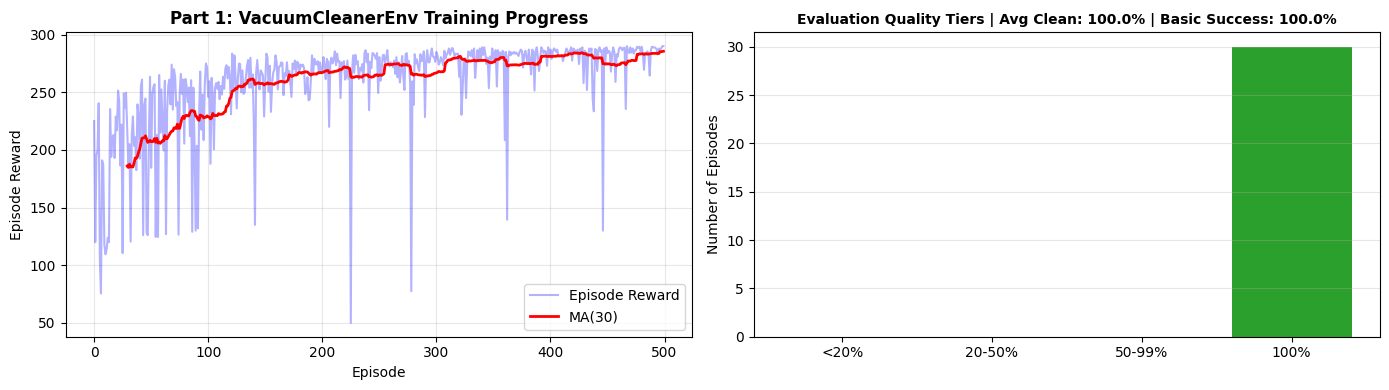

In [13]:
# ============================================================================
# Part 1 visualization
# ============================================================================
# Left plot: training rewards + moving average
# Right plot: distribution by cleaning-quality tiers

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: training curve
axes[0].plot(episode_rewards, alpha=0.3, label='Episode Reward', color='blue')
ma_window = 30
ma_rewards = np.convolve(episode_rewards, np.ones(ma_window)/ma_window, mode='valid')
axes[0].plot(range(ma_window-1, len(episode_rewards)), ma_rewards, label=f'MA({ma_window})', color='red', linewidth=2)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Episode Reward')
axes[0].set_title('Part 1: VacuumCleanerEnv Training Progress', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: quality tiers based on clean ratio
clean_ratios = np.array(eval_clean_ratios)
tier_labels = ['<20%', '20-50%', '50-99%', '100%']
tier_counts = [
    int(np.sum(clean_ratios < 0.20)),
    int(np.sum((clean_ratios >= 0.20) & (clean_ratios < 0.50))),
    int(np.sum((clean_ratios >= 0.50) & (clean_ratios < 1.00))),
    int(np.sum(clean_ratios >= 1.00))
]
tier_colors = ['tab:red', 'tab:orange', 'tab:blue', 'tab:green']

axes[1].bar(tier_labels, tier_counts, color=tier_colors)
axes[1].set_ylabel('Number of Episodes')
axes[1].set_title(
    f'Evaluation Quality Tiers | Avg Clean: {avg_clean_ratio:.1f}% | Basic Success: {basic_success_rate:.1f}%',
    fontsize=10,
    fontweight='bold'
 )
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
plt.close(fig)  # Free figure memory in notebook runtime

### Part 1 Improvement Challenge (Target: Success Rate > 80%)

Use your DQN implementation and try to improve performance with the following ideas:

1. **Reward redesign**
   - Add stronger penalty for wall hits / repeated visits to old cells.
   - Add larger bonus when the agent cleans all cells.

2. **Q-network architecture**
   - Try hidden sizes: `64 / 128 / 256`.
   - Try deeper MLP (more hidden layers).

3. **Hyperparameter tuning**
   - `learning_rate`
   - `batch_size = 32 / 64`
   - `epsilon_decay = 0.99 / 0.995 / 0.998`

Document the best setting that helps you reach **success rate > 80%**.


In [14]:
# ============================================================
# BÀI 3: THỬ NGHIỆM CẢI TIẾN DQN 
# ============================================================

import time

def run_experiment_detailed(hidden_size, lr, epsilon_decay, batch_size,
                             num_episodes=500, label="", seed=42):
    """
    Chạy 1 thực nghiệm và log đầy đủ metrics per-episode.
    
    Returns dict với:
      - label, config
      - episode_rewards       : reward mỗi episode
      - episode_steps         : số bước mỗi episode
      - episode_clean_ratios  : % ô dọn được mỗi episode
      - episode_completions   : 1/0 hoàn thành mỗi episode
      - epsilon_history       : epsilon sau mỗi episode
      - wall_hits_per_ep      : số lần đụng tường mỗi episode
      - repeat_visits_per_ep  : số lần lặp ô mỗi episode
      - train_time_s          : tổng thời gian train (giây)
      - summary               : dict các số tổng hợp
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    env_exp = VacuumCleanerEnv(grid_size=5)

    agent_exp = DQNAgent(
        state_size=51,
        action_size=4,
        learning_rate=lr,
        gamma=0.99
    )
    # Override hidden_size
    agent_exp.q_network      = DQNNetwork(51, 4, hidden_size=hidden_size).to(device)
    agent_exp.target_network = DQNNetwork(51, 4, hidden_size=hidden_size).to(device)
    agent_exp.target_network.load_state_dict(agent_exp.q_network.state_dict())
    agent_exp.target_network.eval()
    agent_exp.optimizer      = optim.Adam(agent_exp.q_network.parameters(), lr=lr)
    agent_exp.epsilon_decay  = epsilon_decay

    ep_rewards, ep_steps, ep_clean, ep_done = [], [], [], []
    ep_epsilon, ep_wall, ep_repeat = [], [], []

    t0 = time.time()

    for episode in range(num_episodes):
        state, _ = env_exp.reset()
        done = False
        ep_r = ep_s = wall_hits = repeat_visits = 0
        prev_pos = env_exp.agent_pos

        while not done:
            action = agent_exp.select_action(state, training=True)
            next_state, reward, terminated, truncated, _ = env_exp.step(action)
            done = terminated or truncated

            # Đếm wall hits và repeat visits từ reward
            if reward == -1.0:
                wall_hits += 1
            elif reward == -0.5:
                repeat_visits += 1

            agent_exp.store_transition(state, action, reward, next_state, done)
            agent_exp.train_step(batch_size)
            ep_r += reward
            ep_s += 1
            state  = next_state

        agent_exp.decay_epsilon()

        cleaned    = (env_exp.num_cells - 1) - len(env_exp.dirty_cells)
        clean_rat  = cleaned / (env_exp.num_cells - 1)

        ep_rewards.append(ep_r)
        ep_steps.append(ep_s)
        ep_clean.append(clean_rat * 100)
        ep_done.append(1 if clean_rat >= 1.0 else 0)
        ep_epsilon.append(agent_exp.epsilon)
        ep_wall.append(wall_hits)
        ep_repeat.append(repeat_visits)

    train_time = time.time() - t0

    summary = {
        "label"           : label,
        "hidden_size"     : hidden_size,
        "lr"              : lr,
        "epsilon_decay"   : epsilon_decay,
        "batch_size"      : batch_size,
        "success_rate"    : np.mean(ep_done[-100:]) * 100,
        "avg_reward"      : np.mean(ep_rewards[-100:]),
        "avg_steps"       : np.mean(ep_steps[-100:]),
        "avg_clean"       : np.mean(ep_clean[-100:]),
        "avg_wall_hits"   : np.mean(ep_wall[-100:]),
        "avg_repeats"     : np.mean(ep_repeat[-100:]),
        "min_reward"      : np.min(ep_rewards[-100:]),
        "max_reward"      : np.max(ep_rewards[-100:]),
        "std_reward"      : np.std(ep_rewards[-100:]),
        "final_epsilon"   : agent_exp.epsilon,
        "train_time_s"    : train_time,
        "ep100_success"   : np.mean(ep_done[:100]) * 100,   # success rate giai đoạn đầu
        "ep300_success"   : np.mean(ep_done[200:300]) * 100, # giữa
        "ep500_success"   : np.mean(ep_done[-100:]) * 100,  # cuối
    }

    print(f"\n[{label}]")
    print(f"  Config   : hidden={hidden_size}, lr={lr}, ε_decay={epsilon_decay}, batch={batch_size}")
    print(f"  Success  : ep1-100={summary['ep100_success']:.1f}% | ep201-300={summary['ep300_success']:.1f}% | ep401-500={summary['ep500_success']:.1f}%")
    print(f"  Avg Reward (last 100): {summary['avg_reward']:.2f}  (min={summary['min_reward']:.1f}, max={summary['max_reward']:.1f}, std={summary['std_reward']:.2f})")
    print(f"  Avg Steps/ep         : {summary['avg_steps']:.1f}")
    print(f"  Avg Wall hits/ep     : {summary['avg_wall_hits']:.1f}")
    print(f"  Avg Repeat visits/ep : {summary['avg_repeats']:.1f}")
    print(f"  Final epsilon        : {summary['final_epsilon']:.4f}")
    print(f"  Train time           : {summary['train_time_s']:.1f}s")

    return {
        "summary"        : summary,
        "ep_rewards"     : ep_rewards,
        "ep_steps"       : ep_steps,
        "ep_clean"       : ep_clean,
        "ep_done"        : ep_done,
        "ep_epsilon"     : ep_epsilon,
        "ep_wall"        : ep_wall,
        "ep_repeat"      : ep_repeat,
    }


# ── Chạy 4 thực nghiệm ────────────────────────────────────────────────────
print("=" * 70)
print("BẢNG THỰC NGHIỆM CẢI TIẾN DQN — CHI TIẾT")
print("=" * 70)

experiments = {}

experiments["Baseline\n(h=128,lr=1e-3,ε=0.995,b=32)"] = run_experiment_detailed(
    hidden_size=128, lr=1e-3, epsilon_decay=0.995, batch_size=32, label="Baseline")

experiments["Large net\n(h=256,lr=1e-3,ε=0.995,b=32)"] = run_experiment_detailed(
    hidden_size=256, lr=1e-3, epsilon_decay=0.995, batch_size=32, label="h=256")

experiments["Slow explore\n(h=128,lr=1e-3,ε=0.998,b=32)"] = run_experiment_detailed(
    hidden_size=128, lr=1e-3, epsilon_decay=0.998, batch_size=32, label="eps=0.998")

experiments["Large batch\n(h=128,lr=1e-3,ε=0.995,b=64)"] = run_experiment_detailed(
    hidden_size=128, lr=1e-3, epsilon_decay=0.995, batch_size=64, label="batch=64")


# ── Bảng tổng hợp ─────────────────────────────────────────────────────────
print("\n" + "=" * 95)
print(f"{'Config':<35} {'Success%':>8} {'AvgRwd':>8} {'Std':>6} {'Steps':>7} {'WallHit':>8} {'Repeat':>8} {'Time(s)':>8}")
print("-" * 95)
for name, data in experiments.items():
    s = data["summary"]
    lbl = name.replace('\n', ' ')
    print(f"{lbl:<35} {s['success_rate']:>7.1f}% {s['avg_reward']:>8.2f} {s['std_reward']:>6.2f} "
          f"{s['avg_steps']:>7.1f} {s['avg_wall_hits']:>8.1f} {s['avg_repeats']:>8.1f} {s['train_time_s']:>8.1f}")
print("=" * 95)

BẢNG THỰC NGHIỆM CẢI TIẾN DQN — CHI TIẾT

[Baseline]
  Config   : hidden=128, lr=0.001, ε_decay=0.995, batch=32
  Success  : ep1-100=84.0% | ep201-300=99.0% | ep401-500=99.0%
  Avg Reward (last 100): 283.33  (min=138.5, max=290.0, std=18.78)
  Avg Steps/ep         : 34.4
  Avg Wall hits/ep     : 1.7
  Avg Repeat visits/ep : 8.7
  Final epsilon        : 0.0816
  Train time           : 89.6s

[h=256]
  Config   : hidden=256, lr=0.001, ε_decay=0.995, batch=32
  Success  : ep1-100=91.0% | ep201-300=100.0% | ep401-500=100.0%
  Avg Reward (last 100): 286.24  (min=234.5, max=290.0, std=7.14)
  Avg Steps/ep         : 30.2
  Avg Wall hits/ep     : 1.3
  Avg Repeat visits/ep : 4.9
  Final epsilon        : 0.0816
  Train time           : 64.4s

[eps=0.998]
  Config   : hidden=128, lr=0.001, ε_decay=0.998, batch=32
  Success  : ep1-100=87.0% | ep201-300=100.0% | ep401-500=100.0%
  Avg Reward (last 100): 276.15  (min=240.5, max=286.0, std=8.05)
  Avg Steps/ep         : 47.3
  Avg Wall hits/ep     :

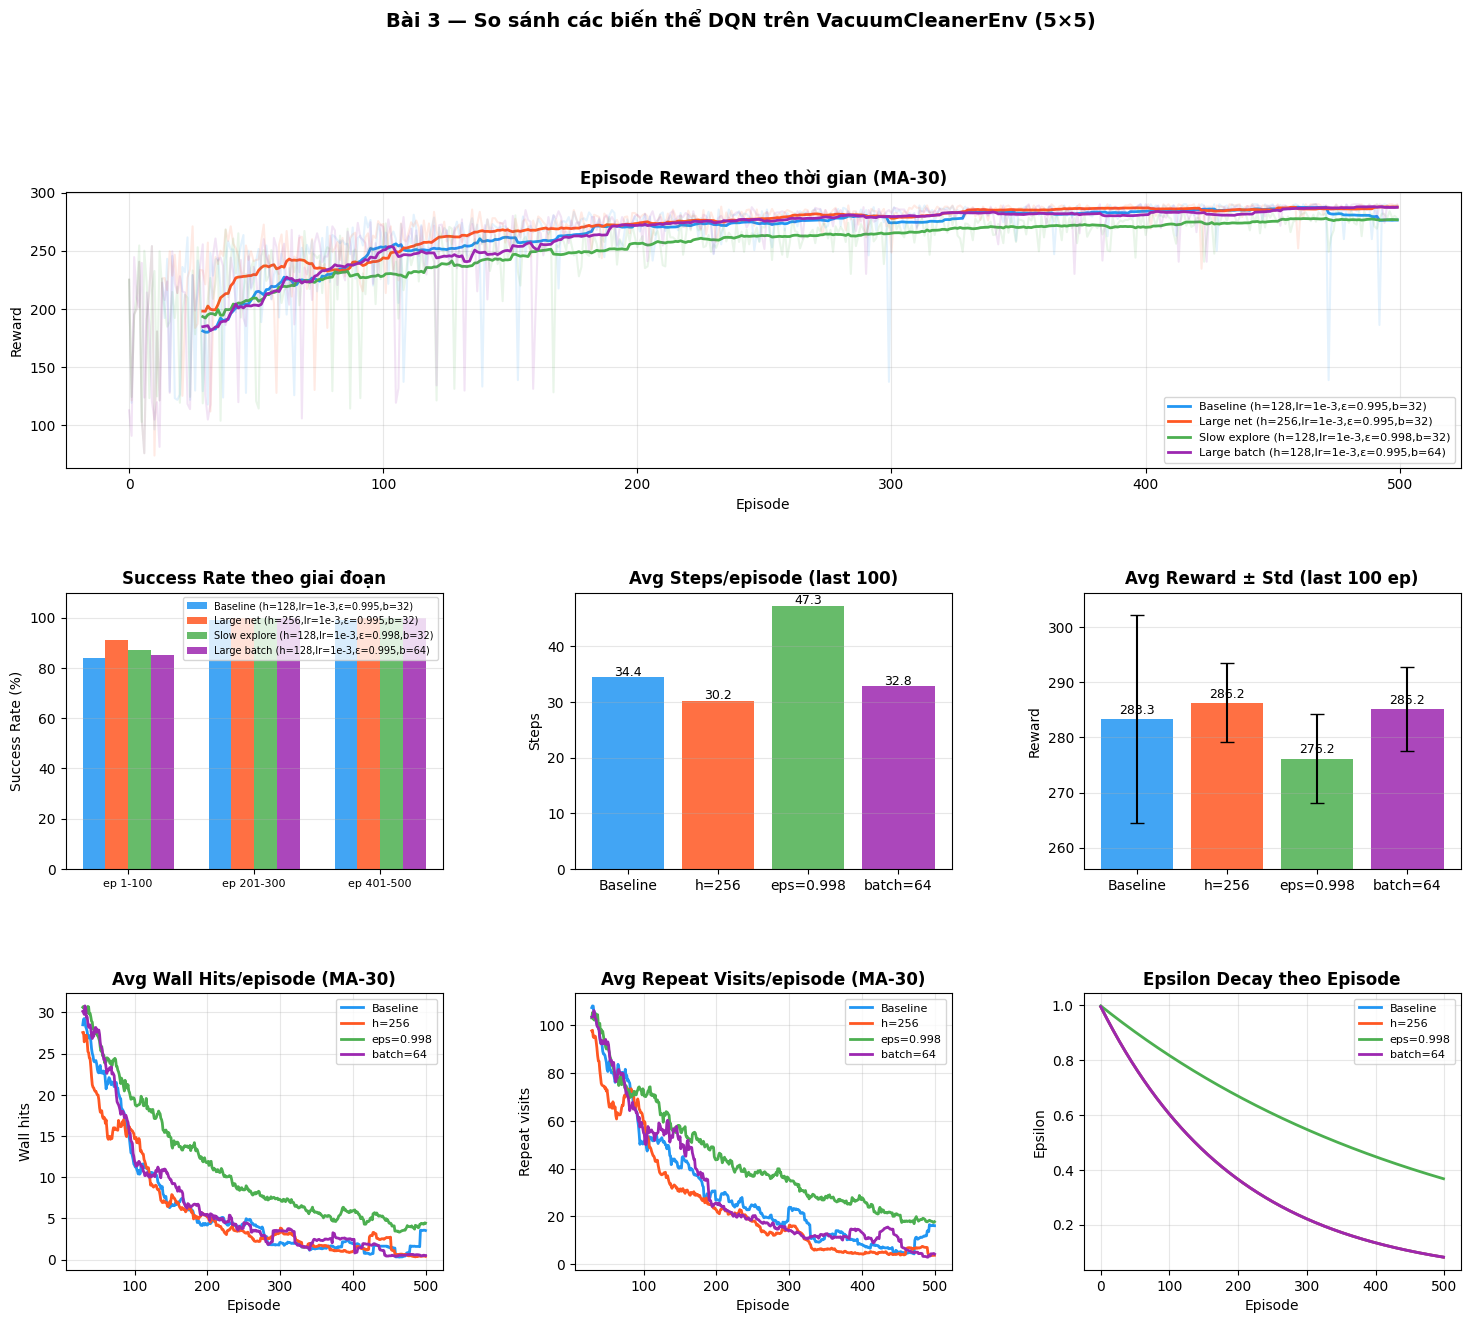

✓ Đã lưu: dqn_experiment_comparison.png


In [15]:
# ── BIỂU ĐỒ SO SÁNH ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

COLORS  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
LABELS  = list(experiments.keys())
DATAS   = list(experiments.values())
MA_WIN  = 30   # Moving average window

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── (A) Episode Reward (moving avg) ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])   # chiếm cả hàng đầu
for i, (name, data) in enumerate(experiments.items()):
    raw = data["ep_rewards"]
    ma  = np.convolve(raw, np.ones(MA_WIN)/MA_WIN, mode='valid')
    ax1.plot(raw, alpha=0.12, color=COLORS[i])
    ax1.plot(range(MA_WIN-1, len(raw)), ma, color=COLORS[i],
             linewidth=2, label=name.replace('\n', ' '))
ax1.set_title("Episode Reward theo thời gian (MA-30)", fontweight='bold')
ax1.set_xlabel("Episode"); ax1.set_ylabel("Reward")
ax1.legend(fontsize=8, loc='lower right'); ax1.grid(alpha=0.3)

# ── (B) Success Rate theo giai đoạn (grouped bar) ────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
phases   = ["ep 1-100", "ep 201-300", "ep 401-500"]
x        = np.arange(len(phases)); width = 0.18
for i, (name, data) in enumerate(experiments.items()):
    s = data["summary"]
    vals = [s["ep100_success"], s["ep300_success"], s["ep500_success"]]
    ax2.bar(x + i*width, vals, width, label=name.replace('\n',' '),
            color=COLORS[i], alpha=0.85)
ax2.set_title("Success Rate theo giai đoạn", fontweight='bold')
ax2.set_xticks(x + width*1.5); ax2.set_xticklabels(phases, fontsize=8)
ax2.set_ylabel("Success Rate (%)"); ax2.set_ylim(0, 110)
ax2.legend(fontsize=7); ax2.grid(alpha=0.3, axis='y')

# ── (C) Avg Steps/episode (last 100) ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
names_short = [d["summary"]["label"] for d in DATAS]
steps_vals  = [d["summary"]["avg_steps"] for d in DATAS]
bars = ax3.bar(names_short, steps_vals, color=COLORS, alpha=0.85)
ax3.set_title("Avg Steps/episode (last 100)", fontweight='bold')
ax3.set_ylabel("Steps"); ax3.grid(alpha=0.3, axis='y')
for bar, v in zip(bars, steps_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{v:.1f}", ha='center', fontsize=9)

# ── (D) Avg Reward ± Std (last 100) ──────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
avg_rwd = [d["summary"]["avg_reward"] for d in DATAS]
std_rwd = [d["summary"]["std_reward"]  for d in DATAS]
bars = ax4.bar(names_short, avg_rwd, color=COLORS, alpha=0.85,
               yerr=std_rwd, capsize=5, error_kw=dict(elinewidth=1.5))
ax4.set_title("Avg Reward ± Std (last 100 ep)", fontweight='bold')
ax4.set_ylabel("Reward"); ax4.set_ylim(min(avg_rwd)-20, max(avg_rwd)+20)
ax4.grid(alpha=0.3, axis='y')
for bar, v in zip(bars, avg_rwd):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{v:.1f}", ha='center', fontsize=9)

# ── (E) Wall hits theo episode (MA) ──────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
for i, (name, data) in enumerate(experiments.items()):
    raw = data["ep_wall"]
    ma  = np.convolve(raw, np.ones(MA_WIN)/MA_WIN, mode='valid')
    ax5.plot(range(MA_WIN-1, len(raw)), ma, color=COLORS[i],
             linewidth=2, label=data["summary"]["label"])
ax5.set_title("Avg Wall Hits/episode (MA-30)", fontweight='bold')
ax5.set_xlabel("Episode"); ax5.set_ylabel("Wall hits")
ax5.legend(fontsize=8); ax5.grid(alpha=0.3)

# ── (F) Repeat visits theo episode (MA) ──────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
for i, (name, data) in enumerate(experiments.items()):
    raw = data["ep_repeat"]
    ma  = np.convolve(raw, np.ones(MA_WIN)/MA_WIN, mode='valid')
    ax6.plot(range(MA_WIN-1, len(raw)), ma, color=COLORS[i],
             linewidth=2, label=data["summary"]["label"])
ax6.set_title("Avg Repeat Visits/episode (MA-30)", fontweight='bold')
ax6.set_xlabel("Episode"); ax6.set_ylabel("Repeat visits")
ax6.legend(fontsize=8); ax6.grid(alpha=0.3)

# ── (G) Epsilon decay comparison ─────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
for i, (name, data) in enumerate(experiments.items()):
    ax7.plot(data["ep_epsilon"], color=COLORS[i],
             linewidth=2, label=data["summary"]["label"])
ax7.set_title("Epsilon Decay theo Episode", fontweight='bold')
ax7.set_xlabel("Episode"); ax7.set_ylabel("Epsilon")
ax7.legend(fontsize=8); ax7.grid(alpha=0.3)

plt.suptitle("Bài 3 — So sánh các biến thể DQN trên VacuumCleanerEnv (5×5)",
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig("dqn_experiment_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print("✓ Đã lưu: dqn_experiment_comparison.png")

---

## Summary and Key Takeaways

## CONGRATULATIONS TEAM!

Congratulations on completing Lab 03.2 - Introduction to Deep Q-Network!

You have successfully:
- Designed and implemented custom Gymnasium environments (VacuumCleanerEnv, LoadBalancingEnv)
- Trained DQN agents on multiple custom environments
- Learned how to use Stable-Baselines3 for production-ready RL
- Compared manual vs. library-based implementations
- Evaluated agents and visualized training progress

You now have the skills to apply DQN to real-world problems!

References: https://gymnasium.farama.org/ | https://stable-baselines3.readthedocs.io/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn

**Last Updated**: March, 2026